# Tips

### Introduction:

This exercise was created based on the tutorial and documentation from [Seaborn](https://stanford.edu/~mwaskom/software/seaborn/index.html)  
The dataset being used is tips from Seaborn.

### Step 1. Import the necessary libraries:

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

### Step 2. Import the dataset from this [address](https://raw.githubusercontent.com/guipsamora/pandas_exercises/master/07_Visualization/Tips/tips.csv).

In [2]:
df=pd.read_csv('https://raw.githubusercontent.com/guipsamora/pandas_exercises/master/07_Visualization/Tips/tips.csv')

### Step 3. Assign it to a variable called tips

In [4]:
tips=df
tips

,Unnamed: 0,total_bill,tip,sex,smoker,day,time,size
0,0,16.99,1.01,Female,No,Sun,Dinner,2
1,1,10.34,1.66,Male,No,Sun,Dinner,3
2,2,21.01,3.50,Male,No,Sun,Dinner,3
3,3,23.68,3.31,Male,No,Sun,Dinner,2
4,4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...,...
239,239,29.03,5.92,Male,No,Sat,Dinner,3
240,240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,242,17.82,1.75,Male,No,Sat,Dinner,2


### Step 4. Delete the Unnamed 0 column

In [5]:
tips.drop(columns='Unnamed: 0',inplace=True)
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


### Step 5. Plot the total_bill column histogram

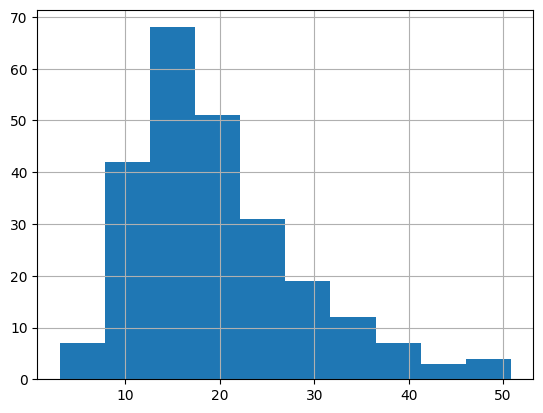

In [8]:
tips['total_bill'].hist()
plt.show()

### Step 6. Create a scatter plot presenting the relationship between total_bill and tip

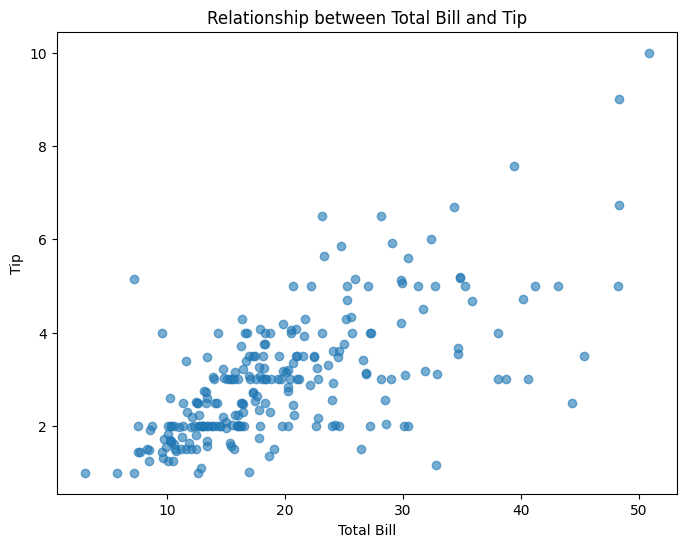

In [10]:

plt.figure(figsize=(8,6))

plt.scatter(
    tips['total_bill'],
    tips['tip'],
    alpha=0.6
)

plt.title('Relationship between Total Bill and Tip')
plt.xlabel('Total Bill')
plt.ylabel('Tip')

plt.show()

### Step 7.  Create one image with the relationship of total_bill, tip and size.
#### Hint: It is just one function.

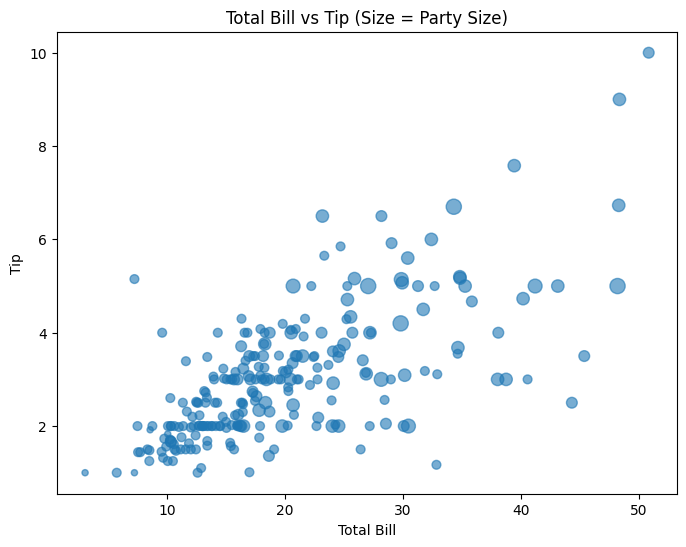

In [11]:

plt.figure(figsize=(8,6))

plt.scatter(
    tips['total_bill'],
    tips['tip'],
    s=tips['size'] * 20,
    alpha=0.6
)

plt.title('Total Bill vs Tip (Size = Party Size)')
plt.xlabel('Total Bill')
plt.ylabel('Tip')

plt.show()

### Step 8. Present the relationship between days and total_bill value

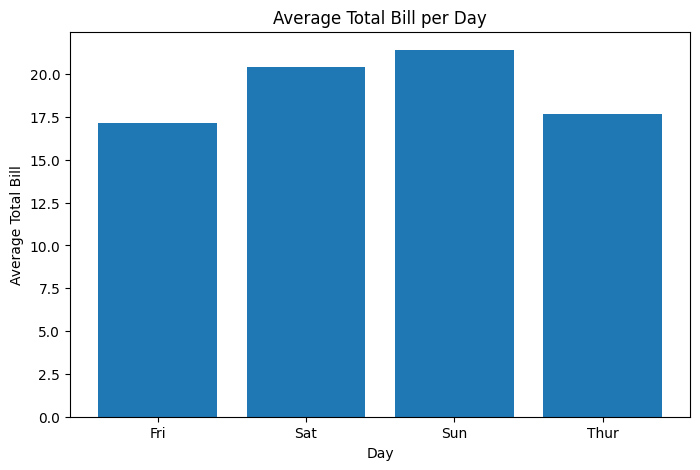

In [12]:
import matplotlib.pyplot as plt

day_avg = tips.groupby('day')['total_bill'].mean()

plt.figure(figsize=(8,5))

plt.bar(day_avg.index, day_avg.values)

plt.title('Average Total Bill per Day')
plt.xlabel('Day')
plt.ylabel('Average Total Bill')

plt.show()

### Step 9. Create a scatter plot with the day as the y-axis and tip as the x-axis, differ the dots by sex

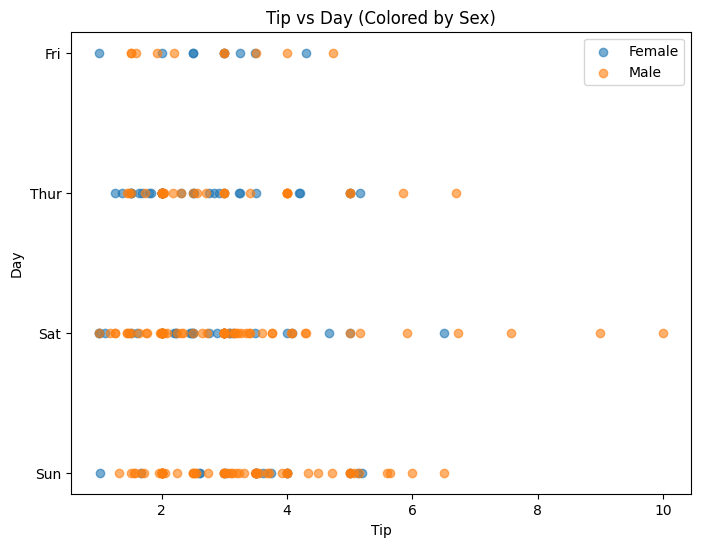

In [13]:

plt.figure(figsize=(8,6))

sexes = tips['sex'].unique()

for s in sexes:
    temp = tips[tips['sex'] == s]

    plt.scatter(
        temp['tip'],
        temp['day'],
        label=s,
        alpha=0.6
    )

plt.title('Tip vs Day (Colored by Sex)')
plt.xlabel('Tip')
plt.ylabel('Day')
plt.legend()

plt.show()

### Step 10.  Create a box plot presenting the total_bill per day differetiation the time (Dinner or Lunch)

### Step 11. Create two histograms of the tip value based for Dinner and Lunch. They must be side by side.

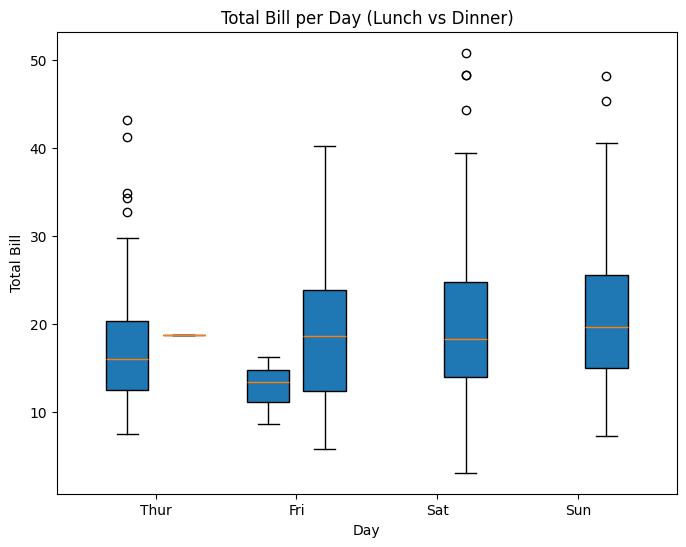

In [15]:

plt.figure(figsize=(8,6))

lunch = tips[tips['time'] == 'Lunch']
dinner = tips[tips['time'] == 'Dinner']

days = ['Thur', 'Fri', 'Sat', 'Sun']

# Boxplot for Lunch
plt.boxplot(
    [lunch[lunch['day'] == d]['total_bill'] for d in days],
    positions=[i - 0.2 for i in range(len(days))],
    widths=0.3,
    patch_artist=True
)

# Boxplot for Dinner
plt.boxplot(
    [dinner[dinner['day'] == d]['total_bill'] for d in days],
    positions=[i + 0.2 for i in range(len(days))],
    widths=0.3,
    patch_artist=True
)

plt.xticks(range(len(days)), days)
plt.xlabel('Day')
plt.ylabel('Total Bill')
plt.title('Total Bill per Day (Lunch vs Dinner)')
plt.show()

### Step 12. Create two scatterplots graphs, one for Male and another for Female, presenting the total_bill value and tip relationship, differing by smoker or no smoker
### They must be side by side.

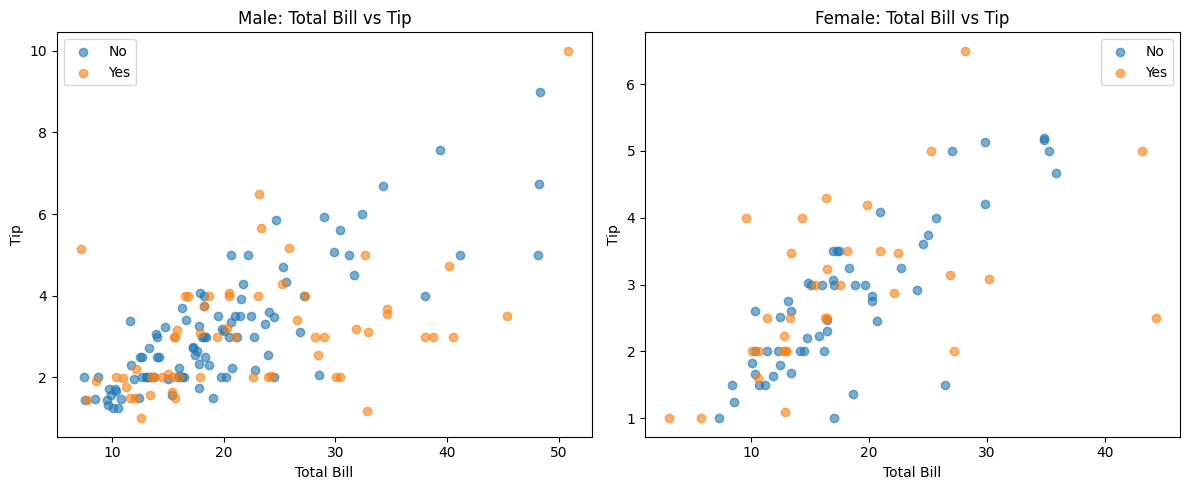

In [16]:

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Male
male = tips[tips['sex'] == 'Male']
for smoker in male['smoker'].unique():
    temp = male[male['smoker'] == smoker]
    axes[0].scatter(
        temp['total_bill'],
        temp['tip'],
        label=smoker,
        alpha=0.6
    )

axes[0].set_title('Male: Total Bill vs Tip')
axes[0].set_xlabel('Total Bill')
axes[0].set_ylabel('Tip')
axes[0].legend()

# Female
female = tips[tips['sex'] == 'Female']
for smoker in female['smoker'].unique():
    temp = female[female['smoker'] == smoker]
    axes[1].scatter(
        temp['total_bill'],
        temp['tip'],
        label=smoker,
        alpha=0.6
    )

axes[1].set_title('Female: Total Bill vs Tip')
axes[1].set_xlabel('Total Bill')
axes[1].set_ylabel('Tip')
axes[1].legend()

plt.tight_layout()
plt.show()

### BONUS: Create your own question and answer it using a graph.